In [67]:
from gapminder import gapminder
from sklearn import linear_model
from sklearn.metrics import r2_score, mean_squared_error
import pandas as pd
import numpy as np
import seaborn.objects as so
import seaborn as sns

from formulaic import Formula

In [68]:
# 1
   
def coefs_rl(x, y):
    x_mean = x.mean()
    y_mean = y.mean()
    beta_1 = ((x-x_mean)*(y-y_mean)).sum() / ((x-x_mean)**2).sum()
    beta_0 = y_mean - beta_1*x_mean

    return beta_1, beta_0

In [69]:
datos = gapminder[gapminder["country"] == "Argentina"]
datos

,country,continent,year,lifeExp,pop,gdpPercap
48,Argentina,Americas,1952,62.485,17876956,5911.315053
49,Argentina,Americas,1957,64.399,19610538,6856.856212
50,Argentina,Americas,1962,65.142,21283783,7133.166023
51,Argentina,Americas,1967,65.634,22934225,8052.953021
52,Argentina,Americas,1972,67.065,24779799,9443.038526
53,Argentina,Americas,1977,68.481,26983828,10079.026740
54,Argentina,Americas,1982,69.942,29341374,8997.897412
55,Argentina,Americas,1987,70.774,31620918,9139.671389
56,Argentina,Americas,1992,71.868,33958947,9308.418710
57,Argentina,Americas,1997,73.275,36203463,10967.281950


In [70]:
coefs_rl(datos["year"], datos["lifeExp"])

(np.float64(0.2317083916083916), np.float64(-389.6063445221445))

In [71]:
X = datos[["year"]]
y = datos["lifeExp"]
modelo = linear_model.LinearRegression()
modelo.fit(X, y)
beta_1 = modelo.coef_[0]
beta_0 = modelo.intercept_

beta_1, beta_0

(np.float64(0.23170839160839155), np.float64(-389.6063445221444))

In [72]:
# 2
inmuebles = pd.read_csv("../Notebooks/Datasets-20260209/inmuebles.csv")
inmuebles.head()

,superficie,precio,zona
0,110.0,454.425690,Zona 2
1,109.0,383.004114,Zona 2
2,101.0,437.362638,Zona 2
3,58.0,304.392486,Zona 3
4,129.0,620.027722,Zona 3


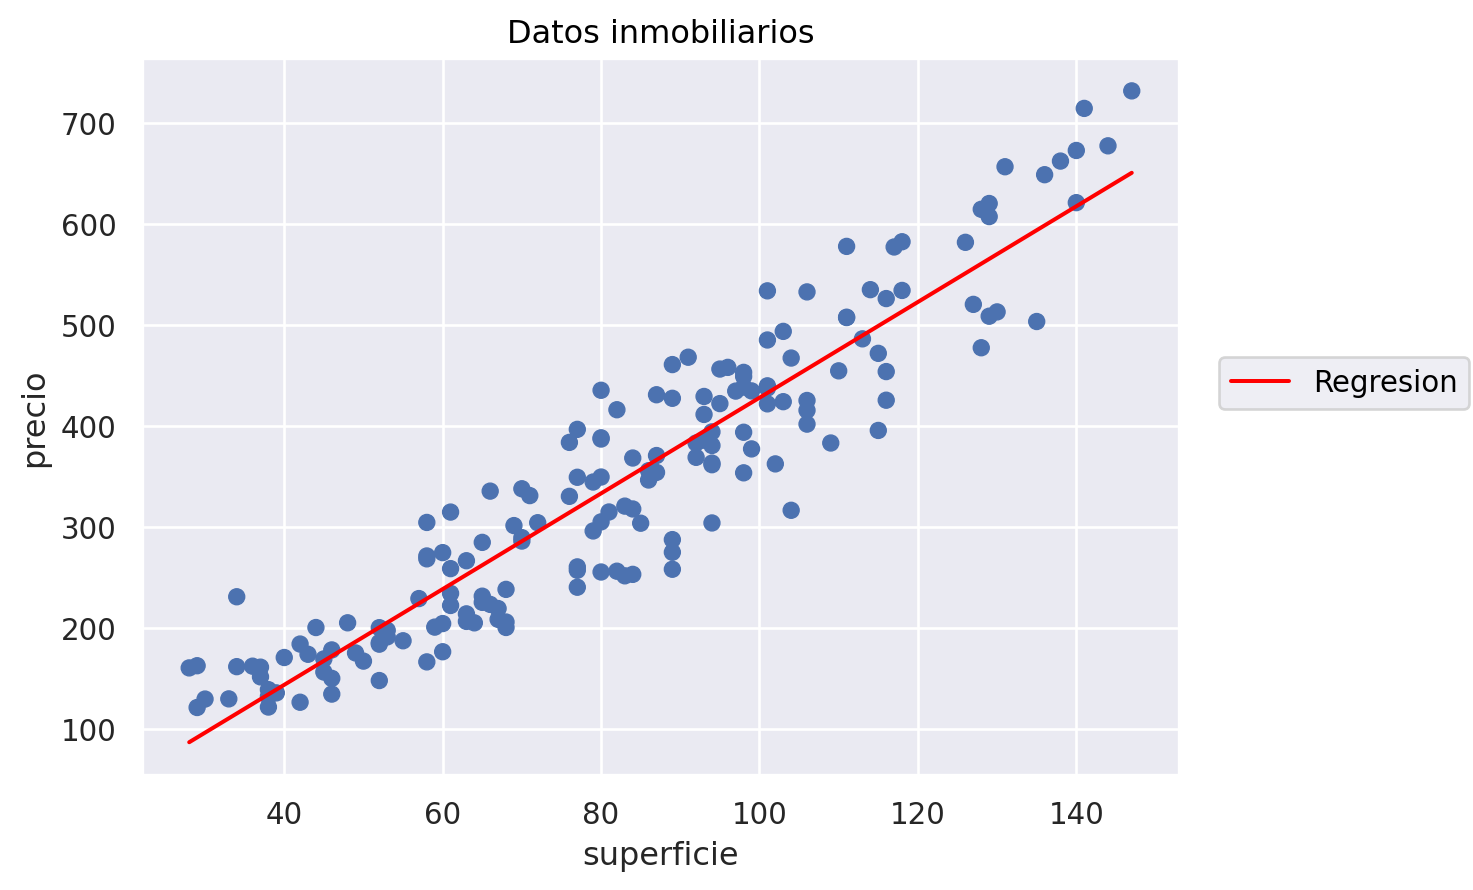

In [73]:
(
    so.Plot(inmuebles, x="superficie")
    .add(so.Dot(), y="precio")
    .add(so.Line(color="red"), so.PolyFit(1), y="precio", label="Regresion")
    .label(title="Datos inmobiliarios")
)

In [74]:
X = inmuebles[["superficie"]]
y = inmuebles["precio"]
modelo = linear_model.LinearRegression()
modelo.fit(X, y)
beta_1, beta_0 = modelo.coef_[0], modelo.intercept_

beta_1, beta_0

(np.float64(4.73579682230239), np.float64(-45.73153403092567))

In [75]:
# Segun el beta_1, podemos decir que el costo del metro cuadrado en la ciudad es de 4.73 millones de pesos
# Esto es asi, ya que beta_1, siendo la pendiente de la recta, nos dice que aumentar 1 metro
# cuadrado hace que aumente 4.73 el precio

In [76]:
def ecm(x, y, pendiente, o_origen):
    return ((y-(o_origen + pendiente*x))**2).sum() / y.size

def r_cuad(x, y, pendiente, o_origen):
    return (((o_origen + pendiente*x)-y.mean())**2).sum() / ((y-y.mean())**2).sum()

In [77]:
ecm(X.superficie, y, beta_1, beta_0), r_cuad(X.superficie, y, beta_1, beta_0)

(np.float64(2630.9300019446955), np.float64(0.8762114698357931))

In [78]:
# ecm esta medido en las mismas unidades que y, al cuadrado
# r_cuad es adimensional

In [79]:
mean_squared_error(y, beta_0 + beta_1*X.superficie), r2_score(y, beta_0 + beta_1*X.superficie)

(2630.9300019446955, 0.8762114698357936)

<Axes: xlabel='zona', ylabel='precio'>

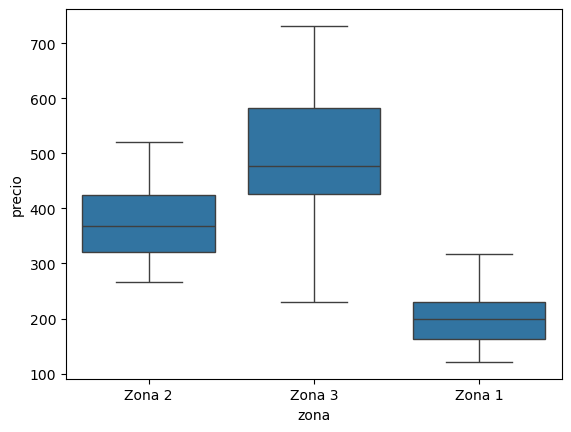

In [80]:
sns.boxplot(inmuebles, x="zona", y="precio")

In [81]:
# Hay mayor variabilidad de precios en la zona 3
# No hay outliers

In [82]:
datos_ajustes = []

for i in range(1, 4):
    zona = f"Zona {i}"
    datos = inmuebles[inmuebles["zona"] == zona]
    X = datos[["superficie"]]
    y = datos["precio"]
    
    modelo = linear_model.LinearRegression()
    modelo.fit(X, y)
    
    beta_1, beta_0 = modelo.coef_[0], modelo.intercept_
    
    ecm = mean_squared_error(y, beta_0 + beta_1*X.superficie)
    r2 = r2_score(y, beta_0 + beta_1*X.superficie)

    datos_ajustes.append((zona, beta_1, beta_0, ecm, r2, modelo))

    print("\n", zona)
    print("beta_1:", beta_1)
    print("beta_0:", beta_0)
    print("ecm:", ecm)
    print("r2:", r2)


 Zona 1
beta_1: 2.442081388302122
beta_0: 58.852000241172306
ecm: 331.22746770470974
r2: 0.855923919218176

 Zona 2
beta_1: 3.206278999112207
beta_0: 80.73010925558549
ecm: 611.4955812522104
r2: 0.866027281146202

 Zona 3
beta_1: 4.560544269538954
beta_0: 24.966485225784936
ecm: 748.8800907160429
r2: 0.9445652745220188


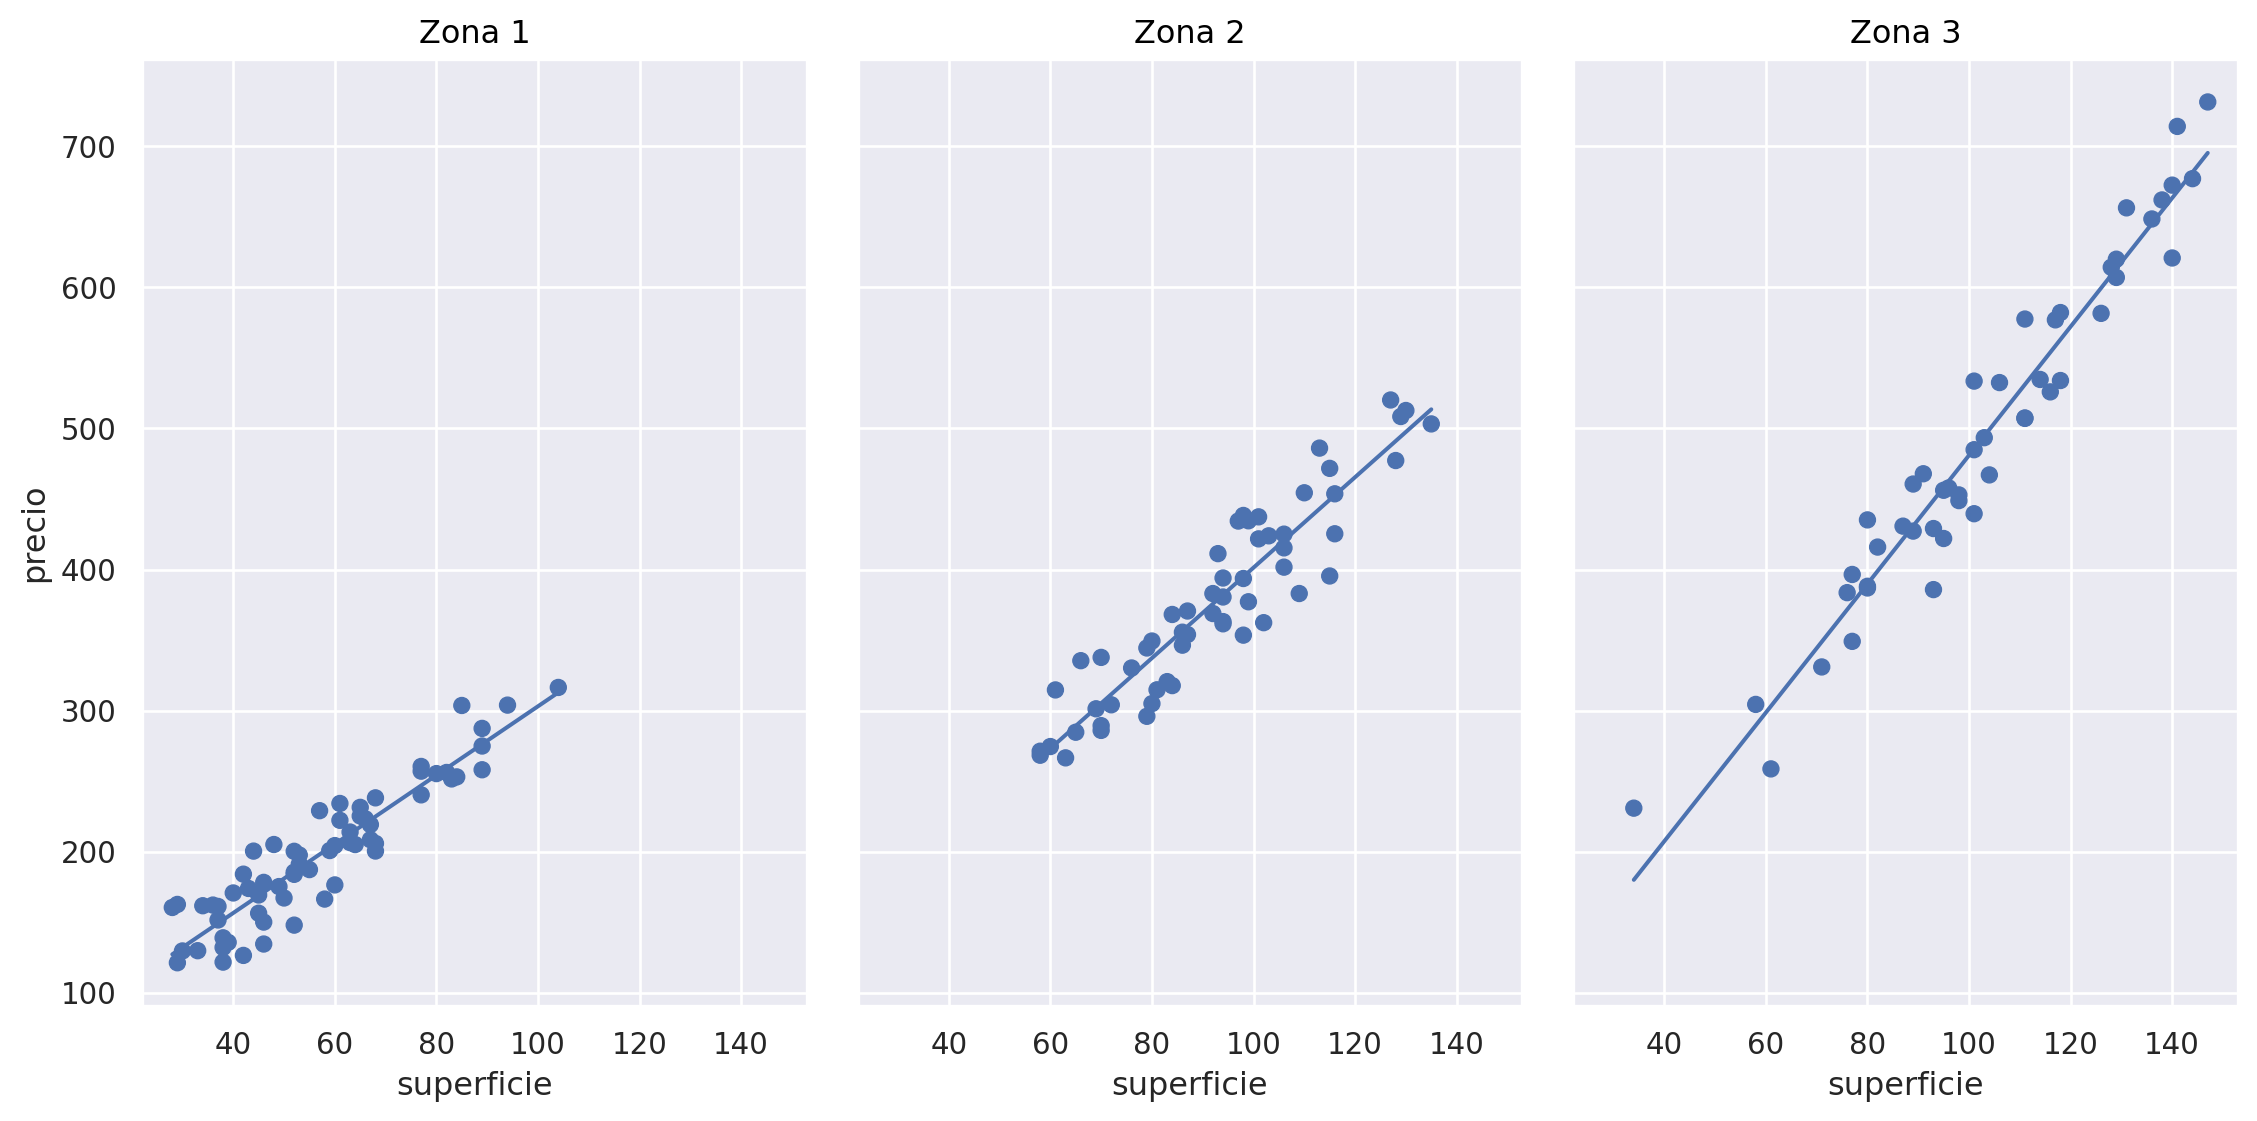

In [83]:
(
    so.Plot(inmuebles, x="superficie")
    .add(so.Dot(), y="precio")
    .add(so.Line(), so.PolyFit(1), y="precio")
    .facet("zona", order=[f"Zona {i}" for i in range(1,4)])
    .layout(size=(12,6))
)

In [84]:
# Un inmueble de 105 metros cuadrados, deberia tener un valor de 4.73 el metro cuadrado, ya que no sabemos a que zona pertenece
# si fuera de la zona 2 podriamos calcularlo con el ajuste correspondiente
sup = 105
datos_ajustes[1][5].predict(np.array([[sup]]))

/home/carlos/miniconda3/envs/venv_labo_datos/lib/python3.12/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


array([417.38940416])

In [85]:
# Si me ofrecen un inmueble de 100 metros cuadrados a 300 en la zona 2, es barato, ya que este
sup = 100
datos_ajustes[1][5].predict(np.array([[sup]]))

/home/carlos/miniconda3/envs/venv_labo_datos/lib/python3.12/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


array([401.35800917])

<Axes: xlabel='zona', ylabel='precio'>

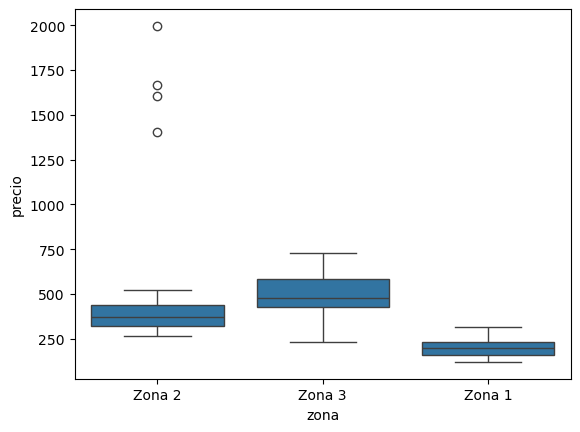

In [86]:
# Outliers
inmuebles_outliers = pd.read_csv("../Notebooks/Datasets-20260209/inmuebles_outliers.csv")
sns.boxplot(inmuebles_outliers, x="zona", y="precio")

In [87]:
datos_ajustes = []

for i in range(1, 4):
    zona = f"Zona {i}"
    datos = inmuebles_outliers[inmuebles_outliers["zona"] == zona]
    X = datos[["superficie"]]
    y = datos["precio"]
    
    modelo = linear_model.LinearRegression()
    modelo.fit(X, y)
    
    beta_1, beta_0 = modelo.coef_[0], modelo.intercept_
    
    ecm = mean_squared_error(y, beta_0 + beta_1*X.superficie)
    r2 = r2_score(y, beta_0 + beta_1*X.superficie)

    datos_ajustes.append((zona, beta_1, beta_0, ecm, r2, modelo))

    print("\n", zona)
    print("beta_1:", beta_1)
    print("beta_0:", beta_0)
    print("ecm:", ecm)
    print("r2:", r2)


 Zona 1
beta_1: 2.4420813883021224
beta_0: 58.85200024117228
ecm: 331.22746770470974
r2: 0.855923919218176

 Zona 2
beta_1: 4.266539806966732
beta_0: 72.89381076100466
ecm: 109771.98270882251
r2: 0.059940627284871595

 Zona 3
beta_1: 4.560544269538954
beta_0: 24.966485225784936
ecm: 748.8800907160429
r2: 0.9445652745220188


In [88]:
# En este caso vemos que en la zona 2 cambio mucho la pendiente debido a los outliers

In [89]:
# 3
datos = sns.load_dataset('tips')
datos.head()

,total_bill,tip,sex,smoker,day,time,size
0,16.99,1.01,Female,No,Sun,Dinner,2
1,10.34,1.66,Male,No,Sun,Dinner,3
2,21.01,3.50,Male,No,Sun,Dinner,3
3,23.68,3.31,Male,No,Sun,Dinner,2
4,24.59,3.61,Female,No,Sun,Dinner,4


In [90]:
X = datos[["total_bill"]] - datos["total_bill"].mean()
y = datos["tip"]

In [91]:
modelo = linear_model.LinearRegression()
modelo.fit(X, y)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [92]:
# Como a total_bill se le esta restando el valor medio, beta_0 va a corresponder al valor medio de y (tips)
modelo.intercept_

np.float64(2.99827868852459)

In [93]:
datos["tip"].mean()

np.float64(2.99827868852459)

In [94]:
# No deberia cambiar beta_1 si se usa total_bill sin restar la media
modelo.coef_[0]

np.float64(0.10502451738435337)

In [95]:
X = datos[["total_bill"]]

In [96]:
modelo = linear_model.LinearRegression()
modelo.fit(X, y)
modelo.intercept_, modelo.coef_[0]

(np.float64(0.9202696135546731), np.float64(0.10502451738435337))

In [97]:
# 4
btc = pd.read_csv("../Notebooks/Datasets-20260209/bitcoin.csv")
btc.head()

,Date,Open,High,Low,Close,Adj Close,Volume
0,2014-09-17,465.864014,468.174011,452.421997,457.334015,457.334015,21056800
1,2014-09-18,456.859985,456.859985,413.104004,424.440002,424.440002,34483200
2,2014-09-19,424.102997,427.834991,384.532013,394.795990,394.795990,37919700
3,2014-09-20,394.673004,423.295990,389.882996,408.903992,408.903992,36863600
4,2014-09-21,408.084991,412.425995,393.181000,398.821014,398.821014,26580100


In [98]:
btc['Date'] = pd.to_datetime(btc['Date'], format = '%Y-%m-%d')

In [99]:
btc_2021 = btc[(btc['Date'] > "2021-01-01") & (btc['Date'] < "2021-07-01")]

In [100]:
btc_2021.head()

,Date,Open,High,Low,Close,Adj Close,Volume
2299,2021-01-02,29376.455078,33155.117188,29091.181641,32127.267578,32127.267578,67865420765
2300,2021-01-03,32129.408203,34608.558594,32052.316406,32782.023438,32782.023438,78665235202
2301,2021-01-04,32810.949219,33440.218750,28722.755859,31971.914063,31971.914063,81163475344
2302,2021-01-05,31977.041016,34437.589844,30221.187500,33992.429688,33992.429688,67547324782
2303,2021-01-06,34013.613281,36879.699219,33514.035156,36824.363281,36824.363281,75289433811


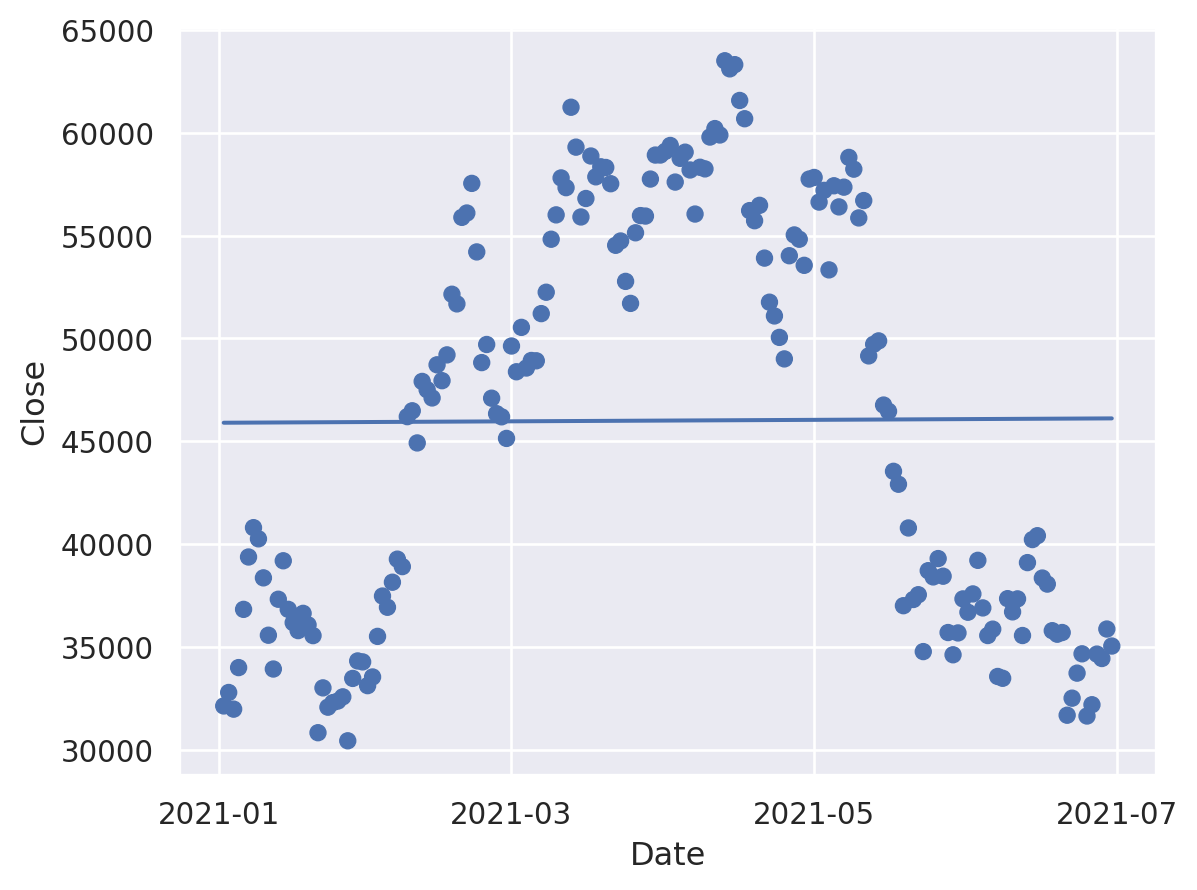

In [101]:
(
    so.Plot(btc_2021, x="Date")
    .add(so.Dot(), y="Close")
    .add(so.Line(), so.PolyFit(1), y="Close")
)

In [102]:
# En este caso vemos que el ajuste lineal no es para nada util a la hora de predecir valores futuros

In [136]:
# 5
healthexp = sns.load_dataset('healthexp')
healthexp.head()

,Year,Country,Spending_USD,Life_Expectancy
0,1970,Germany,252.311,70.6
1,1970,France,192.143,72.2
2,1970,Great Britain,123.993,71.9
3,1970,Japan,150.437,72.0
4,1970,USA,326.961,70.9


In [170]:
japon_data = healthexp[healthexp["Country"] == "Japan"]
japon_data

,Year,Country,Spending_USD,Life_Expectancy
3,1970,Japan,150.437,72.0
8,1971,Japan,163.854,72.9
11,1972,Japan,185.390,73.2
14,1973,Japan,205.778,73.4
17,1974,Japan,242.018,73.7
21,1975,Japan,284.269,74.3
25,1976,Japan,303.725,74.8
28,1977,Japan,340.628,75.3
31,1978,Japan,392.577,75.7
35,1979,Japan,452.931,76.2


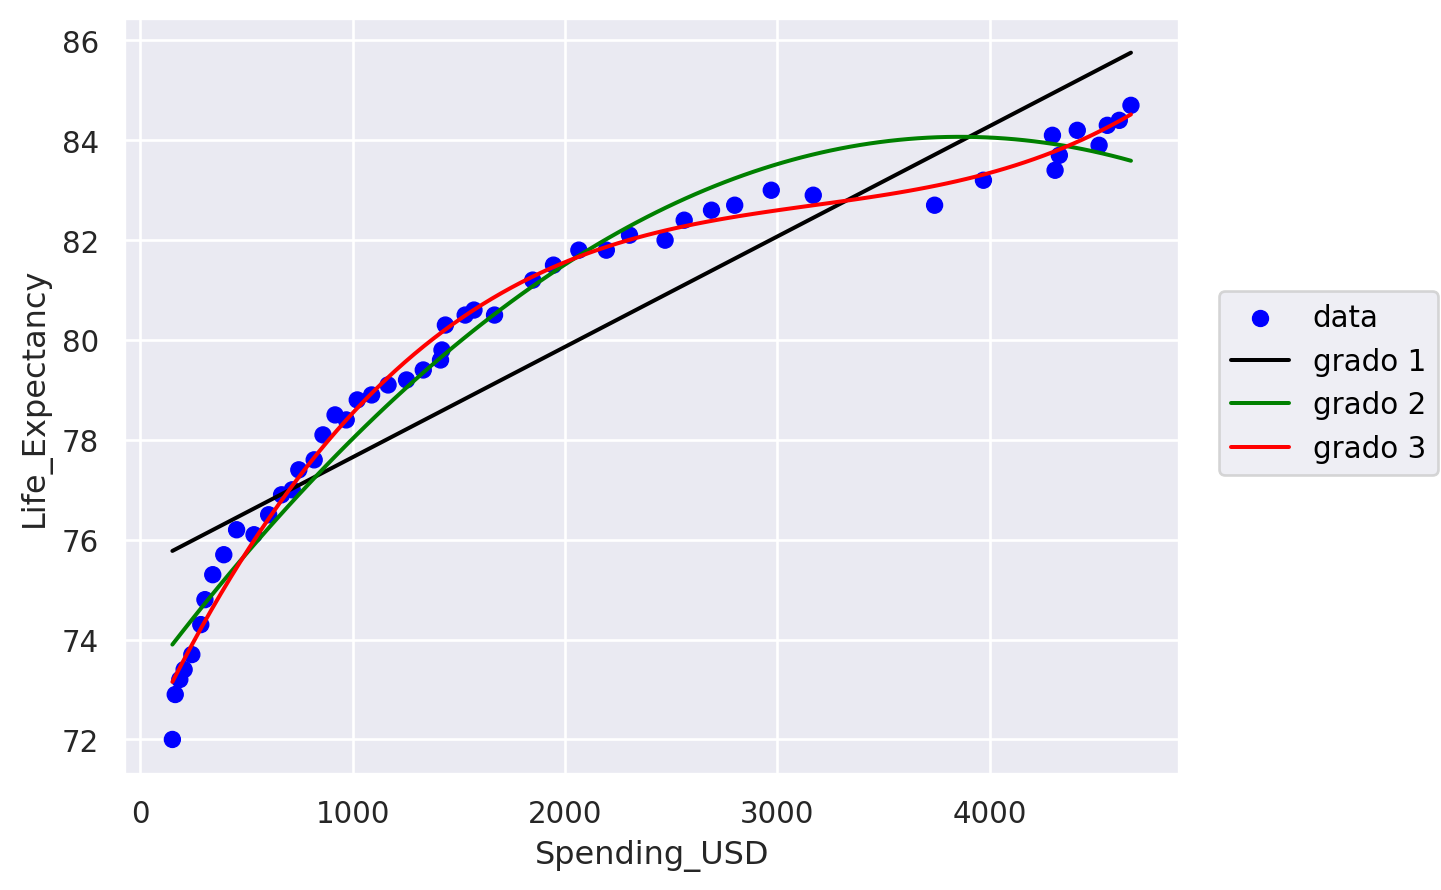

In [156]:
(
    so.Plot(japon_data, x="Spending_USD", y="Life_Expectancy")
    .add(so.Dot(color="blue"), label="data")
    .add(so.Line(color="black"), so.PolyFit(1), label="grado 1")
    .add(so.Line(color="green"), so.PolyFit(2), label="grado 2")
    .add(so.Line(color="red"), so.PolyFit(3), label="grado 3")
)

In [157]:
# El grafico que mejor ajusta en principio es el de grado 3

In [163]:
y, X = Formula('Life_Expectancy ~ poly(Spending_USD, 3, raw=True) - 1').get_model_matrix(japon_data)
y = y.iloc[:, 0]  # Convertimos el DataFrame a Series

In [169]:
X

,"poly(Spending_USD, 3, raw=True)[0]","poly(Spending_USD, 3, raw=True)[1]","poly(Spending_USD, 3, raw=True)[2]"
3,150.437,2.263129e+04,3.404584e+06
8,163.854,2.684813e+04,4.399174e+06
11,185.390,3.436945e+04,6.371753e+06
14,205.778,4.234459e+04,8.713584e+06
17,242.018,5.857271e+04,1.417565e+07
21,284.269,8.080886e+04,2.297146e+07
25,303.725,9.224888e+04,2.801829e+07
28,340.628,1.160274e+05,3.952219e+07
31,392.577,1.541167e+05,6.050267e+07
35,452.931,2.051465e+05,9.291721e+07


In [171]:
y

3      72.0
8      72.9
11     73.2
14     73.4
17     73.7
21     74.3
25     74.8
28     75.3
31     75.7
35     76.2
41     76.1
46     76.5
51     76.9
56     77.0
61     77.4
67     77.6
72     78.1
77     78.5
82     78.4
87     78.8
93     78.9
98     79.1
104    79.2
110    79.4
116    79.8
122    79.6
128    80.3
134    80.5
140    80.6
146    80.5
152    81.2
158    81.5
164    81.8
170    81.8
176    82.1
182    82.0
188    82.4
194    82.6
200    82.7
206    83.0
212    82.9
218    82.7
224    83.2
230    83.4
236    83.7
242    83.9
248    84.1
254    84.2
260    84.3
266    84.4
272    84.7
Name: Life_Expectancy, dtype: float64

In [175]:
# Inicializamos el modelo de regresión. 
modelo = linear_model.LinearRegression(fit_intercept=True)

# Realiza el ajuste
modelo.fit(X, y)

# Como usamos fit_intercept = True, la ordenada al origen está en modelo.intercept_
ordenada_al_origen = modelo.intercept_

# Recuperamos los valores de los demas coeficientes (de menor potencia a la mayor)
coeficientes = modelo.coef_

# Armamos el array con los valores de beta
beta = np.array([ordenada_al_origen, *coeficientes])

# Imprimimos los valores:
print('beta_0: ', beta[0])
print('beta_1: ', beta[1])
print('beta_2: ', beta[2])
print('beta_3: ', beta[3])

beta_0:  71.84403247811416
beta_1:  0.009097662220279315
beta_2:  -2.6841733213765897e-06
beta_3:  2.8216848452775663e-10


In [176]:
modelo.predict(X)

array([73.15287185, 73.26389709, 73.44019242, 73.60492971, 73.8926111 ,
       74.21979264, 74.36751384, 74.64266514, 75.01896143, 75.44021529,
       75.98631631, 76.42175085, 76.78863305, 77.07897034, 77.25414271,
       77.64633236, 77.86154181, 78.14562416, 78.39724222, 78.63608545,
       78.93240621, 79.25164307, 79.5858501 , 79.86736767, 80.15913746,
       80.13735686, 80.20996692, 80.48949587, 80.60615432, 80.86024003,
       81.2701356 , 81.46191486, 81.66967141, 81.86429369, 82.0070335 ,
       82.19263285, 82.2781503 , 82.38617188, 82.4671665 , 82.58038964,
       82.69863814, 83.08605334, 83.31312695, 83.78179526, 83.81600512,
       84.17426426, 83.76110224, 83.968536  , 84.25795922, 84.38645572,
       84.51859525])

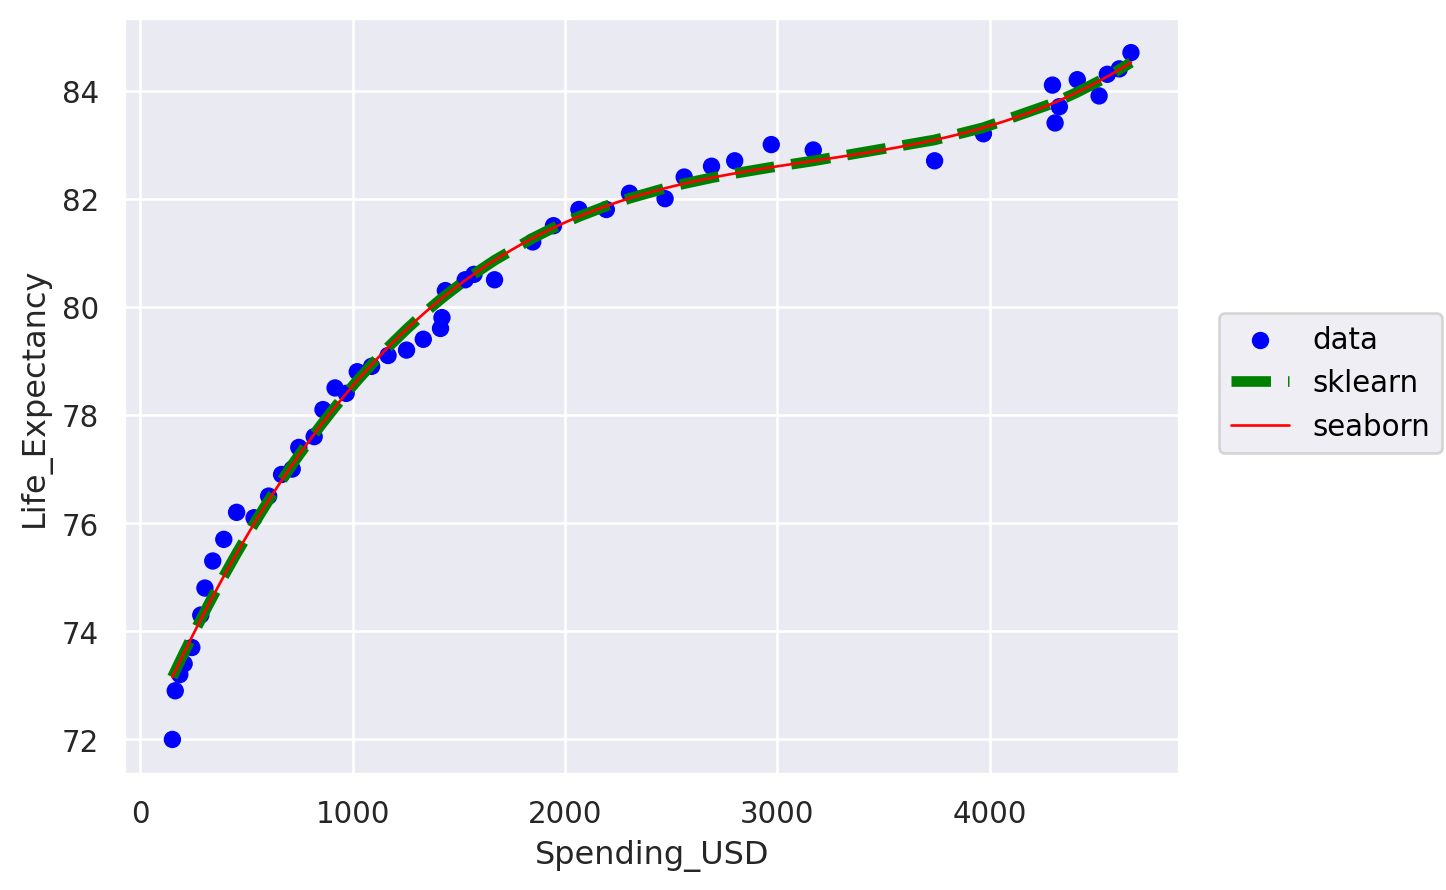

In [184]:
(
    so.Plot(data=japon_data, x="Spending_USD", y="Life_Expectancy")
    .add(so.Dot(color="blue"), label="data")
    .add(so.Line(color="green", linewidth=4, linestyle='--'), x="Spending_USD", y=modelo.predict(X), label="sklearn")
    .add(so.Line(color="red", linewidth=1), so.PolyFit(3), label="seaborn")
)
# Para que grafique bien, tuve que ponerle el x en el grafico de sklearn, sino como que lo lee mal

In [185]:
r2_score(y, modelo.predict(X))

0.9912790933475436

In [186]:
mean_squared_error(y, modelo.predict(X))

0.1075828613870728

In [193]:
valor = 5000
prediccion = beta[0] + beta[1]*valor + beta[2]*valor**2 + beta[3]*valor**3
prediccion

np.float64(85.49907111106556)

/home/carlos/miniconda3/envs/venv_labo_datos/lib/python3.12/site-packages/numpy/lib/_polynomial_impl.py:673: RuntimeWarning: overflow encountered in multiply
  scale = NX.sqrt((lhs * lhs).sum(axis=0))
/home/carlos/miniconda3/envs/venv_labo_datos/lib/python3.12/site-packages/numpy/_core/_methods.py:49: RuntimeWarning: overflow encountered in reduce
  return umr_sum(a, axis, dtype, out, keepdims, initial, where)
/home/carlos/miniconda3/envs/venv_labo_datos/lib/python3.12/site-packages/seaborn/_stats/regression.py:30: RankWarning: Polyfit may be poorly conditioned
  p = np.polyfit(x, y, self.order)


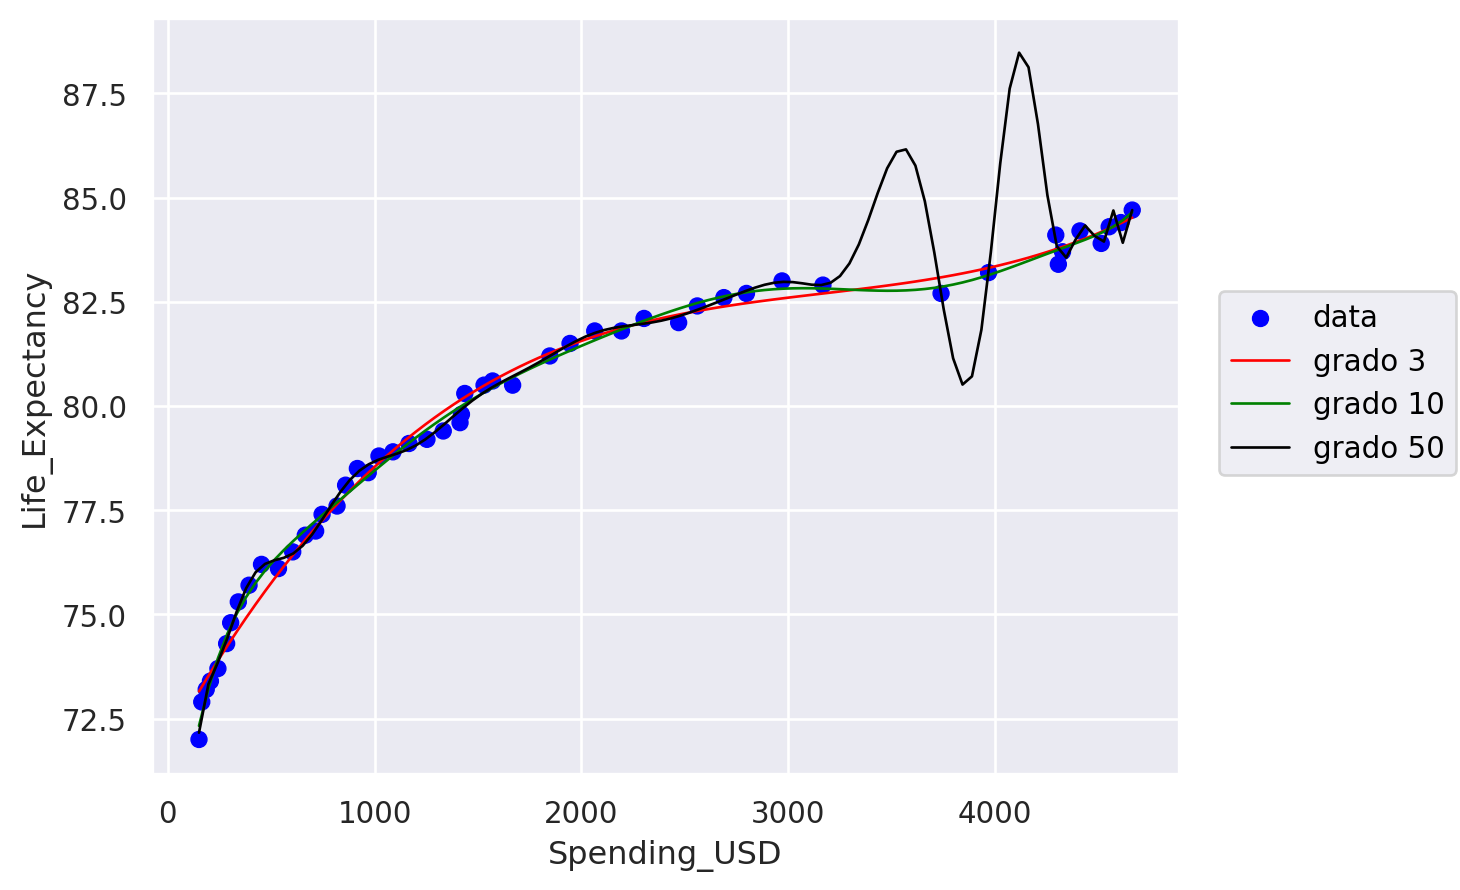

In [197]:
# Agrego uno de grado 10
# Se ve una mejora, pero posiblemente no valga la pena (mucho menos uno de grado 50, overfitting)
(
    so.Plot(data=japon_data, x="Spending_USD", y="Life_Expectancy")
    .add(so.Dot(color="blue"), label="data")
    .add(so.Line(color="red", linewidth=1), so.PolyFit(3), label="grado 3")
    .add(so.Line(color="green", linewidth=1), so.PolyFit(10), label="grado 10")
    .add(so.Line(color="black", linewidth=1), so.PolyFit(50), label="grado 50")
)